ANÁLISE DE DADOS DE UMA EMPRESA DE CONTABILIDADE

In [92]:
#Importando as biblioteca 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

In [93]:
#Carregando conjunto de dados
df = pd.read_csv("dados_contabilidade.csv")

In [ ]:
#Informações gerais 
print(df.info())

In [75]:
#Visualizando as primeiras linhas
df.head()

,ID_Cliente,Nome_Cliente,Segmento,Porte,Data_Contrato,Data_Servico,Tipo_Servico,Valor,Status_Pagamento,Responsavel,NPS,Custo_Operacional,Margem_Lucro
0,Cliente_52,Oficina Mecânica Rápida,Alimentação,Pequeno,2021-07-24,2023-03-21,Balanço Patrimonial,930.07,Pago,Pedro Martins,9,392.32,57.82
1,Cliente_1,Laboratório Farmacêutico,Serviços,Pequeno,2021-07-17,2023-03-31,Consultoria Tributária,1415.32,Atrasado,José Pereira,10,761.61,46.19
2,Cliente_95,Joalheria Brilhante,Alimentação,Grande,2022-11-13,2023-05-05,Imposto de Renda PJ,15338.35,Pendente,Carlos Oliveira,9,5635.19,63.26
3,Cliente_26,Restaurante Sabor,Serviços,Pequeno,2023-07-09,2023-12-06,Folha de Pagamento,479.91,Pendente,Maria Santos,8,247.40,48.45
4,Cliente_50,Loja Fashion,Alimentação,Grande,2021-11-25,2024-09-02,Regularização Fiscal,9025.63,Atrasado,Carlos Oliveira,10,3300.24,63.43


In [94]:
# Converter para datetime, se ainda não for
df['Data_Contrato'] = pd.to_datetime(df['Data_Contrato'], errors='coerce')

# Extrair o ano
df['Ano_Contrato'] = df['Data_Contrato'].dt.year

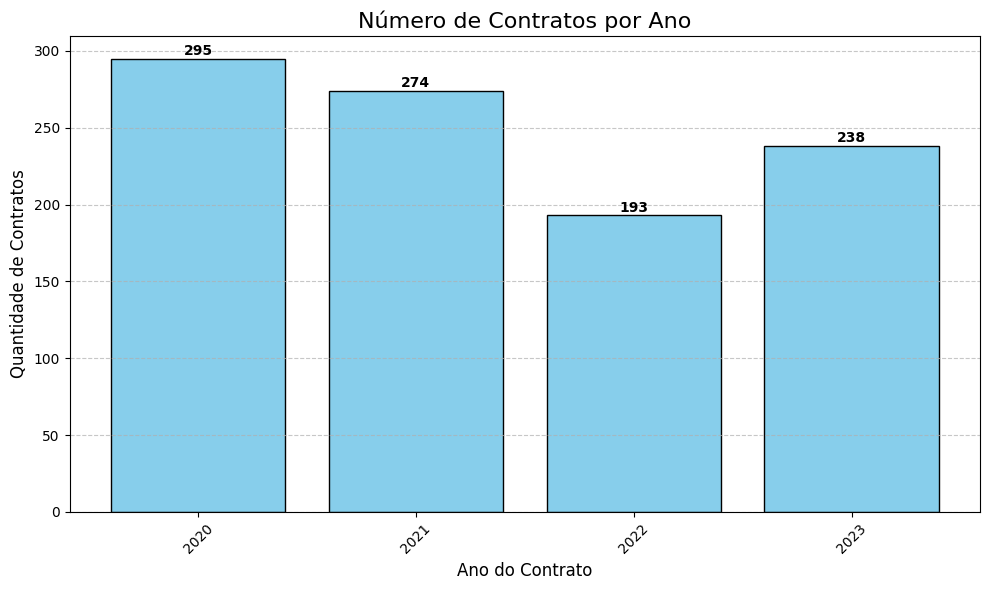

In [95]:
# Contar os contratos por ano
contagem_anos = df['Ano_Contrato'].value_counts().sort_index()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(contagem_anos.index.astype(str), contagem_anos.values, color='skyblue', edgecolor='black')

# Adicionar títulos e rótulos
plt.title('Número de Contratos por Ano', fontsize=16)
plt.xlabel('Ano do Contrato', fontsize=12)
plt.ylabel('Quantidade de Contratos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar rótulos nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#Estatísticas descritivas 
print(df.describe())

In [ ]:
#Distribuição dos clientes por segmento
print(df["Segmento"].value_counts())

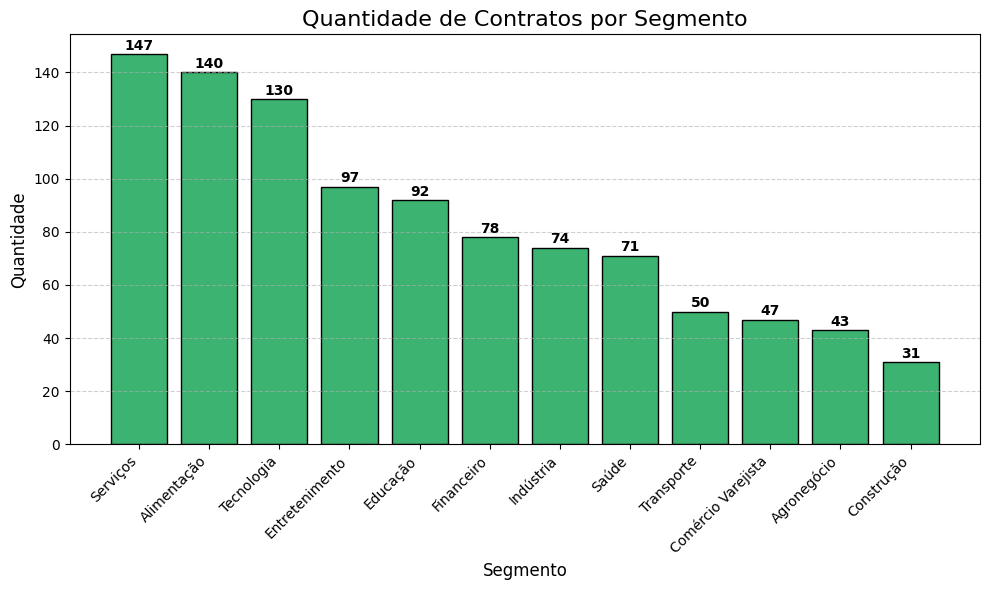

In [98]:
# Contagem por segmento
contagem_segmento = df["Segmento"].value_counts()

# Criar gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(contagem_segmento.index, contagem_segmento.values, color='mediumseagreen', edgecolor='black')

# Título e rótulos
plt.title('Quantidade de Contratos por Segmento', fontsize=16)
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Rótulos nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
#Distribuição dos serviços
contagem_tipo_servico = df["Tipo_Servico"].value_counts()
print(contagem_tipo_servico)

Tipo_Servico
Balanço Patrimonial           78
Folha de Pagamento            77
Declaração IR                 77
Consultoria Contábil          77
Imposto de Renda PJ           74
Escrituração Contábil         74
Contabilidade Fiscal          73
Auditoria                     73
Planejamento Tributário       70
Demonstrativo de Resultado    70
Consultoria Tributária        69
Regularização Fiscal          69
Análise Financeira            62
Abertura de Empresa           57
Name: count, dtype: int64


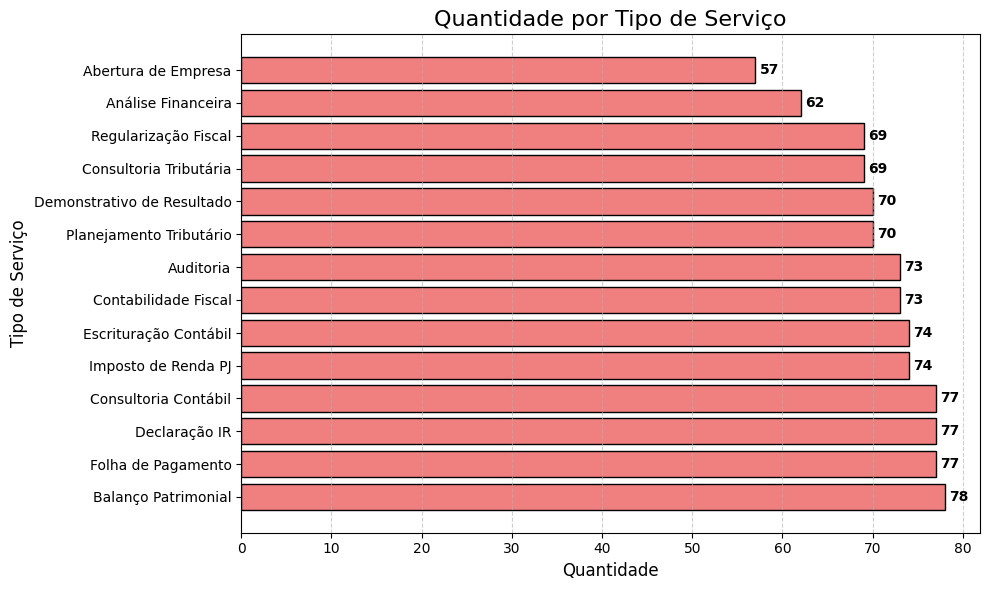

In [32]:
# Gráfico horizontal
plt.figure(figsize=(10, 6))
bars = plt.barh(contagem_tipo_servico.index, contagem_tipo_servico.values, color='lightcoral', edgecolor='black')

# Título e rótulos
plt.title('Quantidade por Tipo de Serviço', fontsize=16)
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Tipo de Serviço', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Rótulo nas barras
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
#Análise de faturamento por porte de empresa 
fat_porte = df.groupby("Porte")["Valor"].agg(["sum","mean","count"])

print(fat_porte)

                sum          mean  count
Porte                                   
Grande   4433841.95  14031.145411    316
Médio    1589648.67   4802.563958    331
Pequeno   616321.03   1745.951926    353


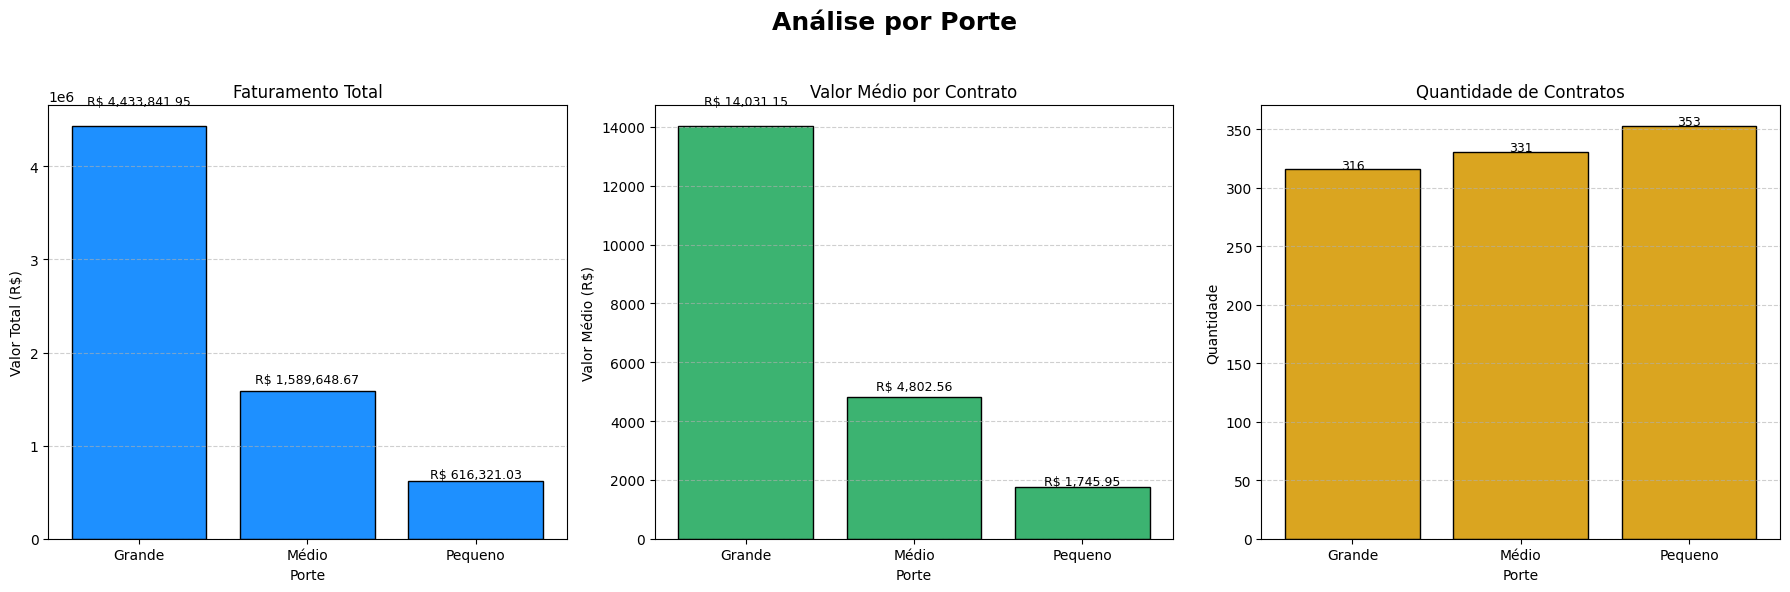

In [34]:
# Criar figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análise por Porte', fontsize=18, fontweight='bold')

# === Gráfico 1: Faturamento total (sum)
axes[0].bar(fat_porte.index, fat_porte['sum'], color='dodgerblue', edgecolor='black')
axes[0].set_title('Faturamento Total')
axes[0].set_xlabel('Porte')
axes[0].set_ylabel('Valor Total (R$)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(fat_porte['sum']):
    axes[0].text(i, v + 0.05 * v, f'R$ {v:,.2f}', ha='center', fontsize=9)

# === Gráfico 2: Valor médio (mean)
axes[1].bar(fat_porte.index, fat_porte['mean'], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Valor Médio por Contrato')
axes[1].set_xlabel('Porte')
axes[1].set_ylabel('Valor Médio (R$)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(fat_porte['mean']):
    axes[1].text(i, v + 0.05 * v, f'R$ {v:,.2f}', ha='center', fontsize=9)

# === Gráfico 3: Quantidade de contratos (count)
axes[2].bar(fat_porte.index, fat_porte['count'], color='goldenrod', edgecolor='black')
axes[2].set_title('Quantidade de Contratos')
axes[2].set_xlabel('Porte')
axes[2].set_ylabel('Quantidade')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(fat_porte['count']):
    axes[2].text(i, v + 0.5, f'{int(v)}', ha='center', fontsize=9)

# Ajuste final
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [50]:
#Análise de Status de pagamento por porte de empresa 
pgt_porte = df.groupby(["Porte", "Status_Pagamento"]).size().reset_index(name="Quantidade")

print(pgt_porte)

     Porte Status_Pagamento  Quantidade
0   Grande         Atrasado         207
1   Grande             Pago          36
2   Grande         Pendente          73
3    Médio         Atrasado         205
4    Médio             Pago          43
5    Médio         Pendente          83
6  Pequeno         Atrasado         218
7  Pequeno             Pago          36
8  Pequeno         Pendente          99


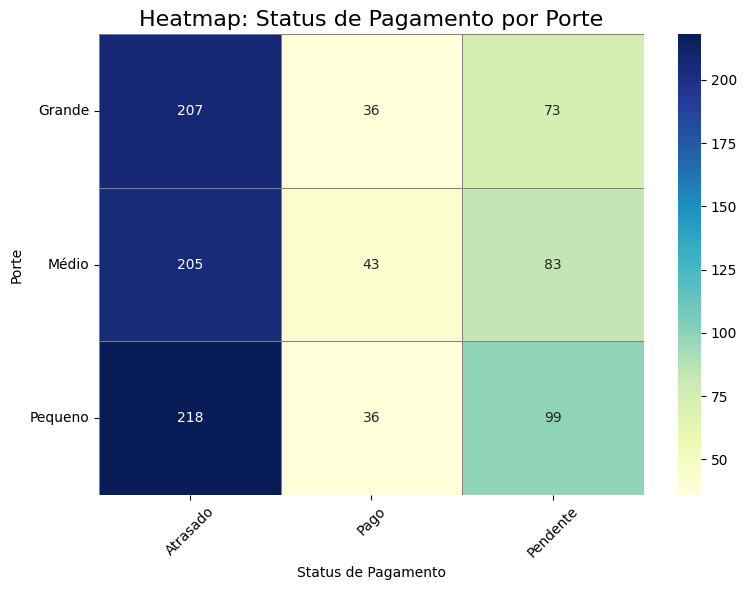

In [52]:
# Pivotar os dados para formato de matriz
pgt_porte_pivot = pgt_porte.pivot(index="Porte", columns="Status_Pagamento", values="Quantidade")
pgt_porte_pivot.fillna(0, inplace=True)  # Preencher valores ausentes com 0

# Criar o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pgt_porte_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, linecolor='gray')

# Ajustes visuais
plt.title("Heatmap: Status de Pagamento por Porte", fontsize=16)
plt.xlabel("Status de Pagamento")
plt.ylabel("Porte")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [54]:
#Análise da média do custo operacional por porte da empresa
custo_porte = df.groupby("Porte")["Custo_Operacional"].agg("mean").round(2)
print(custo_porte)

Porte
Grande     6149.34
Médio      2143.40
Pequeno     779.91
Name: Custo_Operacional, dtype: float64


C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\904992450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=custo_porte, x="Porte", y="Custo_Operacional", palette="Blues_d")


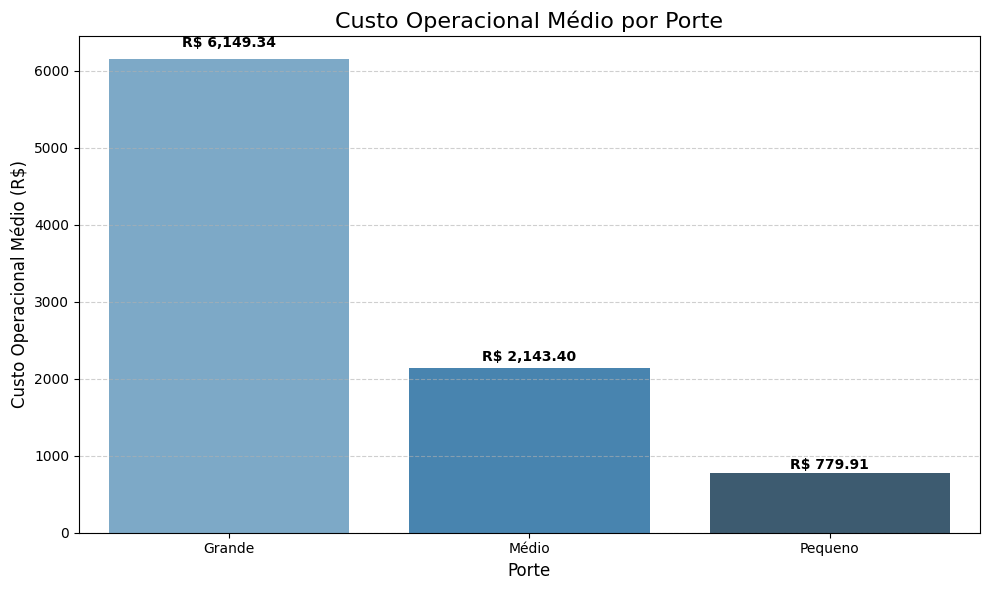

In [55]:
# Agrupando os dados e criando um novo DataFrame
custo_porte = df.groupby("Porte")["Custo_Operacional"].mean().round(2).reset_index()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=custo_porte, x="Porte", y="Custo_Operacional", palette="Blues_d")

# Adicionar rótulos com os valores nas barras
for index, row in custo_porte.iterrows():
    plt.text(index, row["Custo_Operacional"] + 0.02 * row["Custo_Operacional"],
             f'R$ {row["Custo_Operacional"]:,.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Estilização
plt.title("Custo Operacional Médio por Porte", fontsize=16)
plt.xlabel("Porte", fontsize=12)
plt.ylabel("Custo Operacional Médio (R$)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [56]:
# Análise de faturamento por tipo de serviço
fat_servico = df.groupby("Tipo_Servico")["Valor"].agg(["sum","mean","count"]).round(2).sort_values('sum', ascending=False)
print(fat_servico)

                                  sum     mean  count
Tipo_Servico                                         
Planejamento Tributário     653364.46  9333.78     70
Auditoria                   625112.84  8563.19     73
Consultoria Contábil        612784.66  7958.24     77
Regularização Fiscal        600492.73  8702.79     69
Consultoria Tributária      581650.81  8429.72     69
Balanço Patrimonial         519593.52  6661.46     78
Imposto de Renda PJ         518914.47  7012.36     74
Demonstrativo de Resultado  403571.47  5765.31     70
Declaração IR               393909.08  5115.70     77
Escrituração Contábil       386237.52  5219.43     74
Abertura de Empresa         372591.73  6536.70     57
Análise Financeira          343600.75  5541.95     62
Contabilidade Fiscal        325854.86  4463.77     73
Folha de Pagamento          302132.75  3923.80     77


C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\3952813038.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_servico, x="sum", y="Tipo_Servico", ax=axes[0], palette="Blues_d")
C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\3952813038.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_servico, x="mean", y="Tipo_Servico", ax=axes[1], palette="Greens_d")
C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\3952813038.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_servico, x="count", y="Tipo_Servico", ax=ax

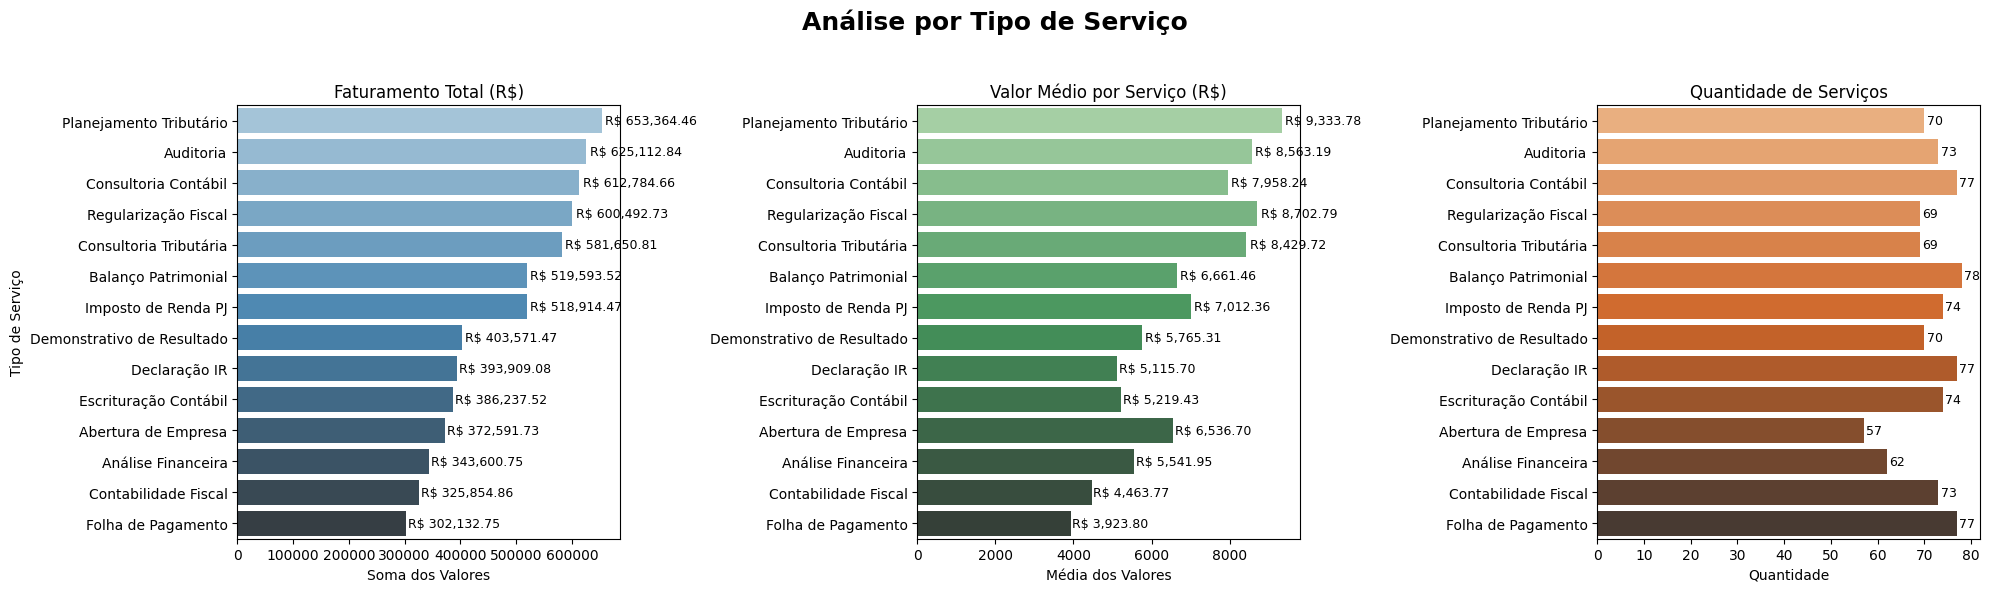

In [57]:
# Resetar o índice para facilitar o uso com seaborn
fat_servico = fat_servico.reset_index()

# Criar subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análise por Tipo de Serviço', fontsize=18, fontweight='bold')

# === Gráfico 1: Faturamento total
sns.barplot(data=fat_servico, x="sum", y="Tipo_Servico", ax=axes[0], palette="Blues_d")
axes[0].set_title("Faturamento Total (R$)")
axes[0].set_xlabel("Soma dos Valores")
axes[0].set_ylabel("Tipo de Serviço")

# Adicionar rótulos nas barras
for i, v in enumerate(fat_servico["sum"]):
    axes[0].text(v + 0.01 * v, i, f'R$ {v:,.2f}', va='center', fontsize=9)

# === Gráfico 2: Valor médio por serviço
sns.barplot(data=fat_servico, x="mean", y="Tipo_Servico", ax=axes[1], palette="Greens_d")
axes[1].set_title("Valor Médio por Serviço (R$)")
axes[1].set_xlabel("Média dos Valores")
axes[1].set_ylabel("")

for i, v in enumerate(fat_servico["mean"]):
    axes[1].text(v + 0.01 * v, i, f'R$ {v:,.2f}', va='center', fontsize=9)

# === Gráfico 3: Quantidade de contratos
sns.barplot(data=fat_servico, x="count", y="Tipo_Servico", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Quantidade de Serviços")
axes[2].set_xlabel("Quantidade")
axes[2].set_ylabel("")

for i, v in enumerate(fat_servico["count"]):
    axes[2].text(v + 0.5, i, f'{int(v)}', va='center', fontsize=9)

# Ajustes finais
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [58]:
# Análise de faturamento por responsável 
fat_responsavel = df.groupby("Responsavel")["Valor"].agg(["sum","mean","count"]).round(2).sort_values("sum", ascending=False)
print(fat_responsavel)

                        sum     mean  count
Responsavel                                
Carlos Oliveira  1272482.04  7806.64    163
Roberto Alves    1141254.90  8210.47    139
Fernanda Lima    1138338.70  7743.80    147
José Pereira      865822.70  6097.34    142
Juliana Costa     614039.16  6977.72     88
Ana Silva         613032.63  5195.19    118
Pedro Martins     507269.37  4411.04    115
Maria Santos      487572.15  5540.59     88


C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\1555725657.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_responsavel, x="sum", y="Responsavel", ax=axes[0], palette="Blues_d")
C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\1555725657.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_responsavel, x="mean", y="Responsavel", ax=axes[1], palette="Greens_d")
C:\Users\jcesa\AppData\Local\Temp\ipykernel_22760\1555725657.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fat_responsavel, x="count", y="Responsave

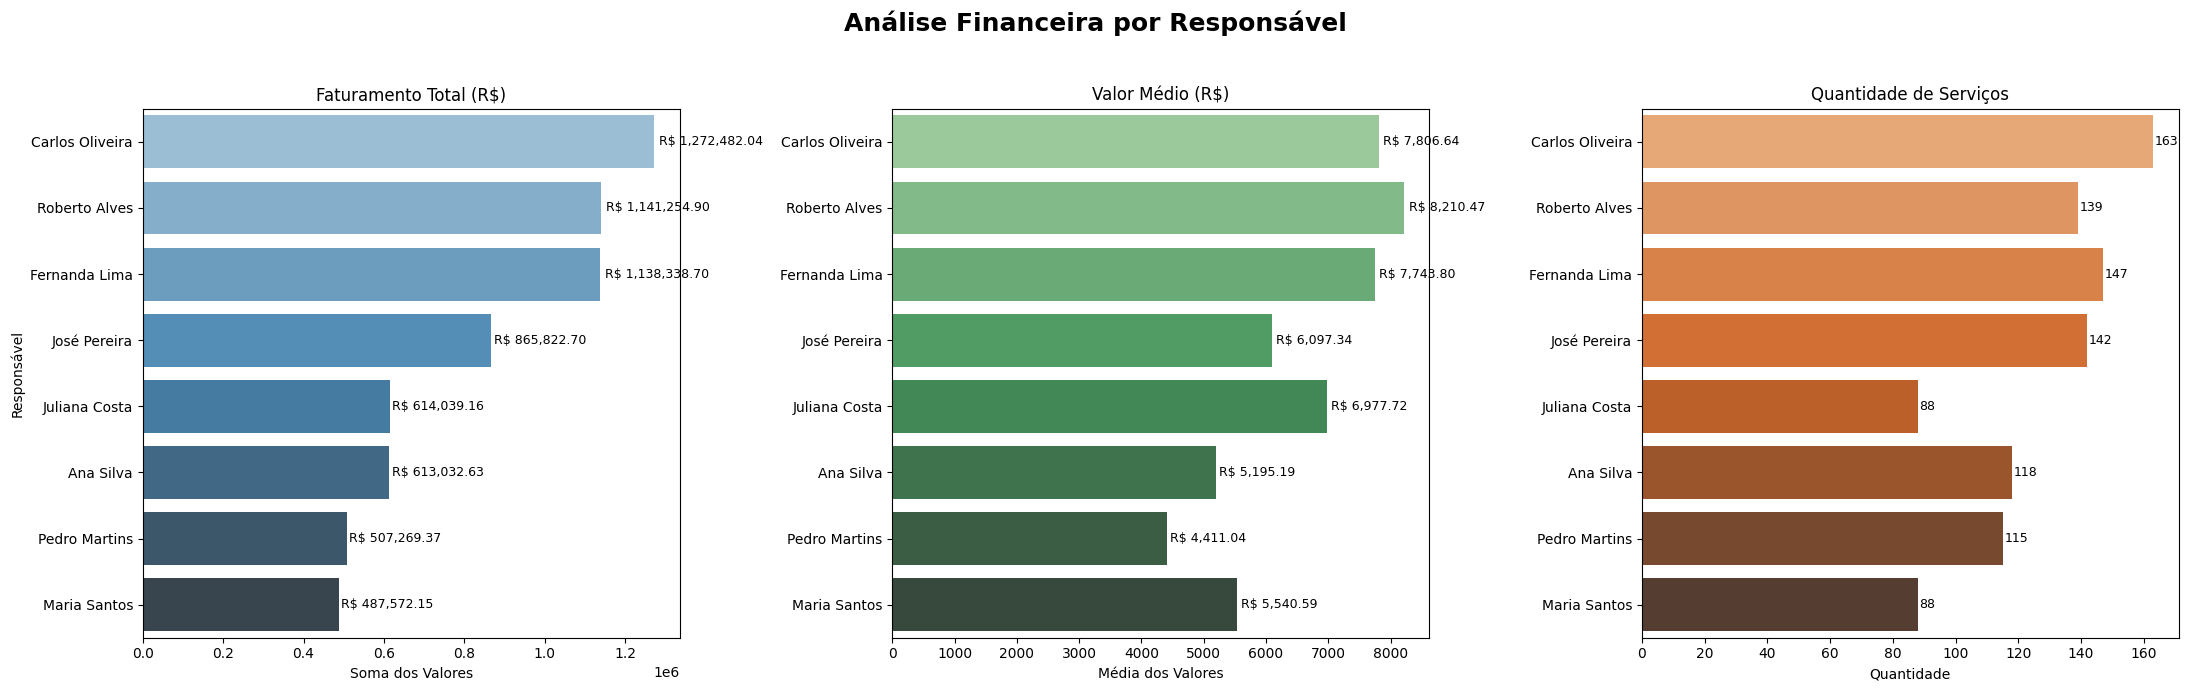

In [59]:
# Agrupar e ordenar
fat_responsavel = df.groupby("Responsavel")["Valor"].agg(["sum", "mean", "count"]).round(2).sort_values("sum", ascending=False).reset_index()

# Criar subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Análise Financeira por Responsável', fontsize=18, fontweight='bold')

# Gráfico 1: Faturamento total
sns.barplot(data=fat_responsavel, x="sum", y="Responsavel", ax=axes[0], palette="Blues_d")
axes[0].set_title("Faturamento Total (R$)")
axes[0].set_xlabel("Soma dos Valores")
axes[0].set_ylabel("Responsável")

for i, v in enumerate(fat_responsavel["sum"]):
    axes[0].text(v + 0.01 * v, i, f'R$ {v:,.2f}', va='center', fontsize=9)

# Gráfico 2: Valor médio
sns.barplot(data=fat_responsavel, x="mean", y="Responsavel", ax=axes[1], palette="Greens_d")
axes[1].set_title("Valor Médio (R$)")
axes[1].set_xlabel("Média dos Valores")
axes[1].set_ylabel("")

for i, v in enumerate(fat_responsavel["mean"]):
    axes[1].text(v + 0.01 * v, i, f'R$ {v:,.2f}', va='center', fontsize=9)

# Gráfico 3: Quantidade de serviços
sns.barplot(data=fat_responsavel, x="count", y="Responsavel", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Quantidade de Serviços")
axes[2].set_xlabel("Quantidade")
axes[2].set_ylabel("")

for i, v in enumerate(fat_responsavel["count"]):
    axes[2].text(v + 0.5, i, f'{int(v)}', va='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [76]:
df['Data_Servico'] = pd.to_datetime(df['Data_Servico'])

faturamento_por_ano = df.groupby(df['Data_Servico'].dt.year)['Valor'].sum().reset_index()
faturamento_por_ano.rename(columns={'Data_Servico': 'Ano', 'Valor': 'Faturamento'}, inplace=True)

print(faturamento_por_ano)

    Ano  Faturamento
0  2020    282352.78
1  2021    547959.58
2  2022   1111116.97
3  2023   1704999.32
4  2024   2201154.95
5  2025    792228.05


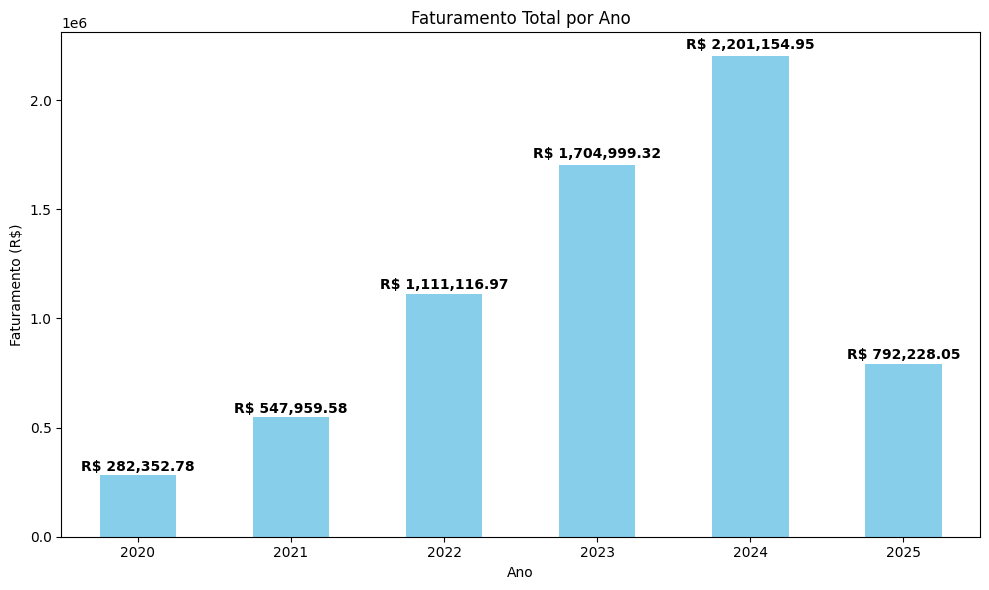

In [77]:
df['Data_Servico'] = pd.to_datetime(df['Data_Servico'])

# Agrupar por ano e somar
faturamento_anual = df.resample('Y', on='Data_Servico')['Valor'].sum().round(2)

plt.figure(figsize=(10,6))
ax = faturamento_anual.plot(kind='bar', color='skyblue')

plt.title('Faturamento Total por Ano')
plt.xlabel('Ano')
plt.ylabel('Faturamento (R$)')

# Ajustar os rótulos do eixo x para mostrar só o ano
anos = faturamento_anual.index.year.astype(str)
ax.set_xticklabels(anos, rotation=0)

# Adicionar valores em cima das barras
for i, v in enumerate(faturamento_anual):
    ax.text(i, v + v*0.01, f'R$ {v:,.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Avaliação do NPS em relação ao porte das empresas e segmento de atuação.

df_NPS = df[df["NPS"]>=8]

print(df_NPS.groupby(["Porte","NPS"])["NPS"].agg("count"))
print("======================================================\n")
print(df_NPS.groupby(["Segmento","NPS"])["NPS"].agg("count"))


Porte    NPS
Grande   8      78
         9      90
         10     72
Médio    8      81
         9      76
         10     96
Pequeno  8      93
         9      97
         10     77
Name: NPS, dtype: int64

Segmento            NPS
Agronegócio         8      14
                    9       9
                    10     10
Alimentação         8      29
                    9      29
                    10     38
Comércio Varejista  8      12
                    9      13
                    10     14
Construção          8       3
                    9      14
                    10      7
Educação            8      22
                    9      27
                    10     26
Entretenimento      8      21
                    9      28
                    10     28
Financeiro          8      19
                    9      21
                    10     15
Indústria           8      16
                    9      21
                    10     18
Saúde               8      29
                 

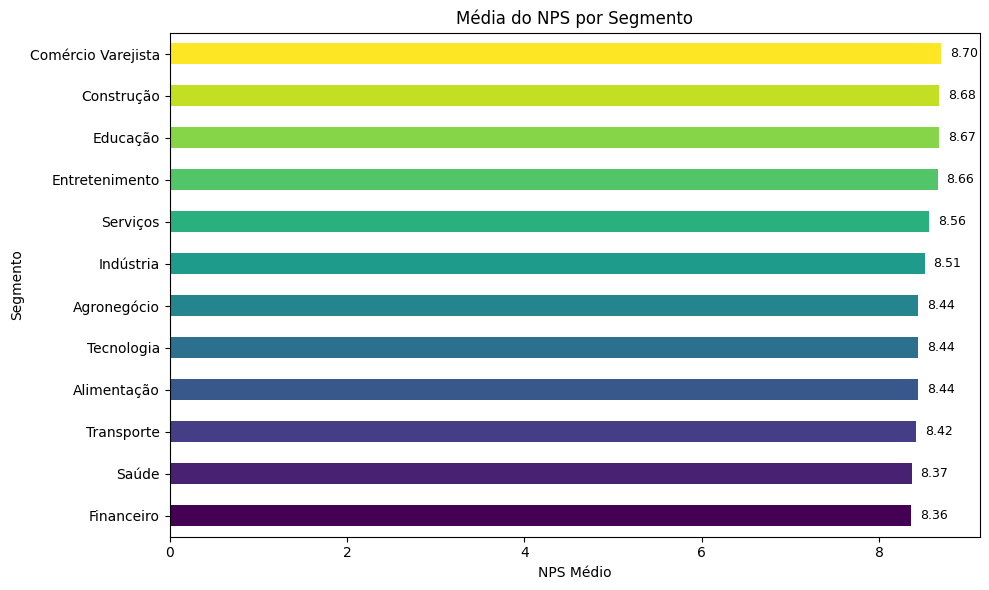

In [83]:

nps_por_segmento = df.groupby('Segmento')['NPS'].mean().sort_values()

# Gerar uma lista de cores com cmap (colormap) - uma cor para cada barra
cores = cm.viridis(np.linspace(0, 1, len(nps_por_segmento)))

plt.figure(figsize=(10, 6))
ax = nps_por_segmento.plot(kind='barh', color=cores)
plt.title('Média do NPS por Segmento')
plt.xlabel('NPS Médio')
plt.ylabel('Segmento')

# Adicionar legenda com valores ao final das barras
for i, v in enumerate(nps_por_segmento):
    ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
readme_content = """# Análise de Dados - Empresa de Contabilidade

## 📊 Descrição do Projeto

Este projeto realiza uma análise completa de dados de uma empresa de contabilidade, incluindo métricas de faturamento, performance por responsável, satisfação de clientes (NPS) e distribuição de serviços.

## 📋 Conteúdo da Análise

### 1. **Contratos por Ano**
- Visualização da quantidade de contratos firmados ao longo dos anos
- Identificação de tendências temporais

### 2. **Distribuição por Segmento**
- Análise de contratos por segmento de atuação
- Gráfico de barras com totais por segmento

### 3. **Tipos de Serviço**
- Distribuição dos serviços prestados
- Representação horizontal para melhor visualização

### 4. **Análise Financeira por Porte**
- Faturamento total, médio e quantidade de contratos por porte de empresa
- Comparação entre portes (Pequena, Média, Grande)

### 5. **Status de Pagamento**
- Heatmap mostrando relacionamento entre porte e status de pagamento
- Identificação de padrões de pagamento

### 6. **Custo Operacional**
- Média de custo operacional por porte de empresa
- Análise de eficiência operacional

### 7. **Faturamento por Tipo de Serviço**
- Análise detalhada com três perspectivas:
    - Faturamento total
    - Valor médio por serviço
    - Quantidade de serviços

### 8. **Análise por Responsável**
- Performance financeira de cada responsável
- Ranking de faturamento, valor médio e volume de serviços

### 9. **Faturamento Anual**
- Série temporal do faturamento por ano
- Tendências de crescimento/queda

### 10. **NPS (Net Promoter Score)**
- Avaliação de satisfação por segmento e porte
- Identificação de clientes promotores (NPS ≥ 8)

## 🛠️ Tecnologias Utilizadas

- **Python 3.x**
- **Pandas**: Manipulação e análise de dados
- **Matplotlib**: Visualização de gráficos
- **Seaborn**: Gráficos estatísticos avançados
- **NumPy**: Operações numéricas
- **Jupyter Notebook**: Ambiente de análise

## 📁 Arquivos Necessários

- `dados_contabilidade.csv`: Dataset principal com informações de contratos

## 🚀 Execução

1. Certifique-se de ter o arquivo `dados_contabilidade.csv` no mesmo diretório
2. Instale as dependências:
     ```bash
     pip install pandas matplotlib seaborn numpy
     ```
3. Execute as células do Jupyter Notebook sequencialmente

## 📊 Insights Principais

- Identificação de padrões de faturamento por porte e segmento
- Análise de eficiência operacional
- Avaliação da satisfação dos clientes
- Performance individual dos responsáveis

## 📈 Possíveis Melhorias

- Previsão de faturamento futuro com modelos de ML
- Análise de sazonalidade
- Clustering de clientes por similaridade
- Dashboard interativo com Plotly ou Power BI

## 📧 Contato

Para dúvidas sobre a análise, entre em contato com o time de dados.

---
*Última atualização: 2024*
"""

# Salvar o arquivo README.md
with open('README.md', 'w', encoding='utf-8') as f:
        f.write(readme_content)

print("✅ Arquivo README.md gerado com sucesso!")